# YOLOv8 + SSAD: Dental Disease Detection — Phase 1 (Colab)

**Phase 1 only:** imgsz=640, baseline learning  
**Classes:** Impacted, Caries, Periapical Lesion, Deep Caries  
**Dataset path:** `/content/drive/MyDrive/YOLOv8_Dentex_2023`

## 0. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
assert os.path.exists("/content/drive/MyDrive/YOLOv8_Dentex_2023"), \
    "❌ Folder YOLOv8_Dentex_2023 not found in MyDrive!"
print("✅ Drive mounted and dataset folder found.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted and dataset folder found.


## 1. Setup

In [2]:
# ============ SETUP ============
import subprocess, sys, os

os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

# GLOBAL FIX: Monkey-patch torch.load for PyTorch 2.6+ (weights_only default changed)
import torch
_orig_torch_load = torch.load
def _patched_torch_load(*args, **kwargs):
    if "weights_only" not in kwargs:
        kwargs["weights_only"] = False
    return _orig_torch_load(*args, **kwargs)
torch.load = _patched_torch_load
print(f"Patched torch.load globally (PyTorch {torch.__version__})")

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "timm==0.9.2", "pycocotools", "tensorboard", "fvcore", "omegaconf"], check=True)
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "wandb", "ray"], capture_output=True)

SSAD_DIR = "/content/SSAD"
WEIGHTS_DIR = "/content/SSAD/yolov8-ssad"

if not os.path.exists(SSAD_DIR):
    subprocess.run(["git", "clone", "https://github.com/Dylonsword/SSAD.git", SSAD_DIR], check=True)

if not os.path.exists(f"{WEIGHTS_DIR}/yolov8l.pt"):
    subprocess.run(["wget", "-q", "-P", WEIGHTS_DIR,
                    "https://github.com/ultralytics/assets/releases/download/v8.1.0/yolov8l.pt"], check=True)

# Patch train_ssad.py: remove auto-execution
ssad_script = f"{WEIGHTS_DIR}/train_ssad.py"
with open(ssad_script, "r") as f: content = f.read()
marker = 'ssad_model = YOLO("yolov8l.yaml"'
if marker in content and "# PATCHED" not in content:
    patched = content[:content.index(marker)] + "# PATCHED\n"
    with open(ssad_script, "w") as f: f.write(patched)
    print("Patched train_ssad.py")

# Patch torch.load for PyTorch 2.6+
tasks_file = f"{WEIGHTS_DIR}/ultralytics/nn/tasks.py"
with open(tasks_file, "r") as f: tc = f.read()
if 'weights_only=False' not in tc:
    tc = tc.replace('torch.load(file, map_location="cpu")', 'torch.load(file, map_location="cpu", weights_only=False)')
    with open(tasks_file, "w") as f: f.write(tc)
    print("Patched tasks.py")

# Patch torch_utils.py
tu_file = f"{WEIGHTS_DIR}/ultralytics/utils/torch_utils.py"
with open(tu_file, "r") as f: tu = f.read()
if 'weights_only=False' not in tu:
    tu = tu.replace('torch.load(f, map_location=torch.device("cpu"))', 'torch.load(f, map_location=torch.device("cpu"), weights_only=False)')
    with open(tu_file, "w") as f: f.write(tu)
    print("Patched torch_utils.py")

# Patch raytune callback
with open(f"{WEIGHTS_DIR}/ultralytics/utils/callbacks/raytune.py", "w") as f:
    f.write("# Disabled\ncallbacks = {}\n")

# === FIX: Patch SSADLoss to generate token_mask if missing (mosaic drops it) ===
loss_file = f"{WEIGHTS_DIR}/ultralytics/utils/loss.py"
with open(loss_file, "r") as f: lc = f.read()
if "# MOSAIC_MASK_FIX" not in lc:
    old_call = '''    def __call__(self, preds, batch):
        main_preds = preds
        main_loss, main_loss_detach = self.main_criterion(main_preds, batch)
        # do the auxi loss
        auxi_loss = self.model.ssad_head(imgs=batch["img"], masks=batch["token_mask"], encoder=self.model.model, task_m="yolo")'''
    new_call = '''    def __call__(self, preds, batch):
        # MOSAIC_MASK_FIX: generate token_mask on-the-fly if mosaic augmentation dropped it
        if "token_mask" not in batch or batch["token_mask"] is None:
            import numpy as np
            B, _, H, W = batch["img"].shape
            mask_patch = 32; model_patch = 2
            rand_size = H // mask_patch; scale = mask_patch // model_patch
            token_count = rand_size ** 2; mask_count = int(np.ceil(token_count * 0.6))
            masks = []
            for _ in range(B):
                mask = np.zeros(token_count, dtype=int)
                mask[np.random.permutation(token_count)[:mask_count]] = 1
                mask = mask.reshape(rand_size, rand_size).repeat(scale,0).repeat(scale,1)
                masks.append(torch.from_numpy(mask))
            batch["token_mask"] = torch.stack(masks, 0).to(batch["img"].device)
        main_preds = preds
        main_loss, main_loss_detach = self.main_criterion(main_preds, batch)
        # do the auxi loss
        auxi_loss = self.model.ssad_head(imgs=batch["img"], masks=batch["token_mask"], encoder=self.model.model, task_m="yolo")'''
    lc = lc.replace(old_call, new_call)
    with open(loss_file, "w") as f: f.write(lc)
    print("Patched SSADLoss: auto-generate token_mask for mosaic compatibility")

# === FIX: Remove token_mask from dataset.py (mosaic corrupts it) ===
ds_file = f"{WEIGHTS_DIR}/ultralytics/data/dataset.py"
with open(ds_file, "r") as f: ds_lines = f.readlines()
patched = False
new_lines = []
for line in ds_lines:
    if "token_mask" in line and "mask_gen" in line:
        new_lines.append(line.split('"token_mask"')[0] + '# REMOVED: token_mask generated in SSADLoss\n')
        patched = True
    elif "token_mask" in line and "torch.from_numpy" in line:
        new_lines.append('                continue  # skip token_mask, generated in SSADLoss\n')
        patched = True
    elif "token_mask" in line and "torch.stack" in line:
        continue
    else:
        new_lines.append(line)
if patched:
    with open(ds_file, "w") as f: f.writelines(new_lines)
    print("Patched dataset.py: removed token_mask from data pipeline")

import glob
for cache in glob.glob(f"{WEIGHTS_DIR}/dentex_datasets/*.cache"):
    os.remove(cache)
    print(f"Deleted stale cache: {cache}")

print("Setup complete!")

Patched torch.load globally (PyTorch 2.11.0+cu128)
Setup complete!


## 2. Dataset Conversion

In [3]:
# ============ DATASET ============
import os, shutil, random
from collections import defaultdict

DRIVE_ROOT  = "/content/drive/MyDrive/YOLOv8_Dentex_2023/YOLOv8_Dentex_2023"
WEIGHTS_DIR = "/content/SSAD/yolov8-ssad"
DST         = "/content/SSAD/yolov8-ssad/dentex_datasets"

# Dataset source is the Google Drive folder
SRC = DRIVE_ROOT
assert os.path.exists(os.path.join(SRC, "train", "images")), \
    f"❌ Expected train/images inside {SRC}"
print(f"Dataset: {SRC}")

CLASS_REMAP = {0: 1, 1: 3, 2: 0, 3: 2}
SSAD_NAMES  = {0: "Impacted", 1: "Caries", 2: "Periapical Lesion", 3: "Deep Caries"}

def polygon_to_bbox(c):
    xs, ys = c[0::2], c[1::2]
    return ((min(xs)+max(xs))/2, (min(ys)+max(ys))/2, max(xs)-min(xs), max(ys)-min(ys))

def convert_label(sp, dp):
    counts = defaultdict(int); lines = []
    with open(sp) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls = CLASS_REMAP.get(int(parts[0]), int(parts[0]))
            coords = [float(x) for x in parts[1:]]
            cx,cy,w,h = coords if len(coords)==4 else polygon_to_bbox(coords)
            lines.append(f"{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n"); counts[cls] += 1
    with open(dp, "w") as f: f.writelines(lines)
    return counts

os.makedirs(f"{DST}/images", exist_ok=True)
os.makedirs(f"{DST}/labels", exist_ok=True)

trainval, test_s = [], []
for split in ["train", "valid", "test"]:
    idir, ldir = f"{SRC}/{split}/images", f"{SRC}/{split}/labels"
    if not os.path.exists(idir): continue
    for img in sorted(os.listdir(idir)):
        if not img.lower().endswith((".jpg",".jpeg",".png")): continue
        lbl = os.path.splitext(img)[0]+".txt"
        lp = f"{ldir}/{lbl}" if os.path.exists(f"{ldir}/{lbl}") else None
        (test_s if split=="test" else trainval).append((f"{idir}/{img}", lp))

random.seed(42); random.shuffle(trainval)
split_idx = int(len(trainval) * 0.85)
train_s = trainval[:split_idx]
val_s   = trainval[split_idx:]

total = defaultdict(lambda: defaultdict(int))
train_paths, val_paths, test_paths = [], [], []
for name, samples, paths in [("train",train_s,train_paths),("val",val_s,val_paths),("test",test_s,test_paths)]:
    for ip, lp in samples:
        fn = os.path.basename(ip); ln = os.path.splitext(fn)[0]+".txt"
        di, dl = f"{DST}/images/{fn}", f"{DST}/labels/{ln}"
        if not os.path.exists(di): shutil.copy2(ip, di)
        if lp:
            for c,n in convert_label(lp, dl).items(): total[name][c] += n
        else: open(dl,"w").close()
        paths.append(os.path.abspath(di))

with open(f"{DST}/train.txt","w") as f: f.writelines(p+"\n" for p in train_paths)
with open(f"{DST}/val.txt","w") as f:   f.writelines(p+"\n" for p in val_paths)
with open(f"{DST}/test.txt","w") as f:  f.writelines(p+"\n" for p in test_paths)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")
for c in sorted(SSAD_NAMES):
    print(f"  {SSAD_NAMES[c]:>20}: train={total['train'][c]:>4}, val={total['val'][c]:>4}, test={total['test'][c]:>4}")
assert len(train_paths) > 0, "No training data found!"

Dataset: /content/drive/MyDrive/YOLOv8_Dentex_2023/YOLOv8_Dentex_2023
Train: 541 | Val: 96 | Test: 165
              Impacted: train= 461, val=  63, test= 153
                Caries: train=1797, val= 293, test= 445
     Periapical Lesion: train= 118, val=  14, test=  42
           Deep Caries: train= 426, val=  86, test= 131


## 3. Configuration

In [4]:
# ============ CONFIG ============
import sys, os, re
WEIGHTS_DIR = "/content/SSAD/yolov8-ssad"
DST         = "/content/SSAD/yolov8-ssad/dentex_datasets"

with open(f"{WEIGHTS_DIR}/dentex.yaml", "w") as f:
    f.write(f'''train: {DST}/train.txt
val: {DST}/val.txt
test: {DST}/test.txt
nc: 4
names: ["Impacted", "Caries", "Periapical Lesion", "Deep Caries"]
''')

yp = f"{WEIGHTS_DIR}/yolov8.yaml"
with open(yp) as f: c = f.read()
c = re.sub(r'loss_type:.*', 'loss_type: "l1"', c)
with open(yp, "w") as f: f.write(c)

sys.path.insert(0, WEIGHTS_DIR)
os.environ["DEFAULT_CFG_PATH"] = f"{WEIGHTS_DIR}/hyp.ssad.yaml"
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

try:
    from timm.models.layers import trunc_normal_
except ImportError:
    import timm.layers; sys.modules["timm.models.layers"] = timm.layers

from ultralytics.models import YOLO
from ultralytics.nn.tasks import SSADModel
import torch
print(f"OK! CUDA={torch.cuda.is_available()}, GPUs={torch.cuda.device_count()}")

OK! CUDA=True, GPUs=1


## 4. Phase 1: Baseline Training (imgsz=640)
Learn basic feature representations with standard settings.

In [5]:
# ============ PHASE 1: BASELINE (imgsz=640) ============
import os, sys, torch
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()

WEIGHTS_DIR = "/content/SSAD/yolov8-ssad"
sys.path.insert(0, WEIGHTS_DIR)
os.chdir(WEIGHTS_DIR)

from ultralytics.models import YOLO
from train_ssad import SSADTrainer

model_p1 = YOLO("yolov8l.yaml", task="ssad").load(f"{WEIGHTS_DIR}/yolov8l.pt")

p1_results = model_p1.train(
    cfg=f"{WEIGHTS_DIR}/hyp.ssad.yaml",
    data=f"{WEIGHTS_DIR}/dentex.yaml",
    batch=2,
    epochs=50,
    imgsz=640,
    device="0",
    exist_ok=True,
    name="phase1-640",
    task="ssad",
    ssad_flag=True,
    ssad_mask_patch_size=32,
    ssad_model_patch_size=2,
    ssad_mask_ratio=0.6,
    ssad_heavily=True,
    ssad_loss_scale=0.1,
    patience=20,
    workers=2,         # Colab: 4 thường lỗi DataLoader
    save_period=5,     # Auto-save mỗi 5 epoch phòng Colab disconnect
    # Mild augmentation for stable learning
    mosaic=0.3,
    mixup=0.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    cls=0.7,
    label_smoothing=0.05,
    trainer=SSADTrainer,
)
print("Phase 1 complete!")

Using the SSAD weights transferred
Transferred 589/611 items from pretrained weights
Ultralytics YOLOv8.2.18 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=ssad, mode=train, model=yolov8l.yaml, data=/content/SSAD/yolov8-ssad/dentex.yaml, epochs=50, time=None, patience=20, batch=2, imgsz=640, save=True, save_period=5, cache=False, device=0, workers=2, project=None, name=phase1-640, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=False, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=

100%|██████████| 755k/755k [00:00<00:00, 45.6MB/s]



                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  3    279808  ultralytics.nn.modules.block.C2f             [128, 128, 3, True]           
  3                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  4                  -1  6   2101248  ultralytics.nn.modules.block.C2f             [256, 256, 6, True]           
  5                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  6                  -1  6   8396800  ultralytics.nn.modules.block.C2f             [512, 512, 6, True]           
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512

/content/SSAD/yolov8-ssad/train_ssad.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.amp)
train: Scanning /content/SSAD/yolov8-ssad/dentex_datasets/labels... 541 images, 12 backgrounds, 0 corrupt: 100%|██████████| 541/541 [00:00<00:00, 1995.98it/s]

train: WARNING ⚠️ /content/SSAD/yolov8-ssad/dentex_datasets/images/train_377_png.rf.8e5cd687e1aea391a4d8d4b02acc3a05.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/SSAD/yolov8-ssad/dentex_datasets/images/train_377_png.rf.d17825512ffa14faab8214e912e7e213.jpg: 1 duplicate labels removed
train: New cache created: /content/SSAD/yolov8-ssad/dentex_datasets/labels.cache


...

      50/50      5.27G     0.7327     0.8867     0.9764    0.09844          1        640: 100%|██████████| 271/271 [03:54<00:00,  1.15it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 24/24 [00:01<00:00, 14.58it/s]

                   all         96        456      0.722      0.617      0.676      0.518



50 epochs completed in 3.430 hours.
Optimizer stripped from /content/SSAD/runs/ssad/phase1-640/weights/last.pt, 92.3MB
Optimizer stripped from /content/SSAD/runs/ssad/phase1-640/weights/best.pt, 92.3MB

Validating /content/SSAD/runs/ssad/phase1-640/weights/best.pt...
Ultralytics YOLOv8.2.18 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8l summary (fused): 298 layers, 45934428 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 24/24 [00:01<00:00, 13.27it/s]


                   all         96        456       0.72      0.633      0.682      0.521
              Impacted         96         63      0.906      0.917      0.952      0.737
                Caries         96        293      0.572      0.534      0.605      0.471
     Periapical Lesion         96         14      0.628      0.429      0.439      0.313
           Deep Caries         96         86      0.775      0.651      0.731      0.564
Speed: 0.3ms preprocess, 9.4ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/SSAD/runs/ssad/phase1-640
Phase 1 complete!


## 5. Save Phase 1 Weights to Google Drive

Phase 1 run dir: /content/SSAD/runs/ssad/phase1-640
  ✅ Saved best.pt → /content/drive/MyDrive/YOLOv8_Dentex_2023/phase1_outputs/phase1_best.pt (88.0 MB)
  ✅ Saved last.pt → /content/drive/MyDrive/YOLOv8_Dentex_2023/phase1_outputs/phase1_last.pt (88.0 MB)
  ✅ Saved results.png


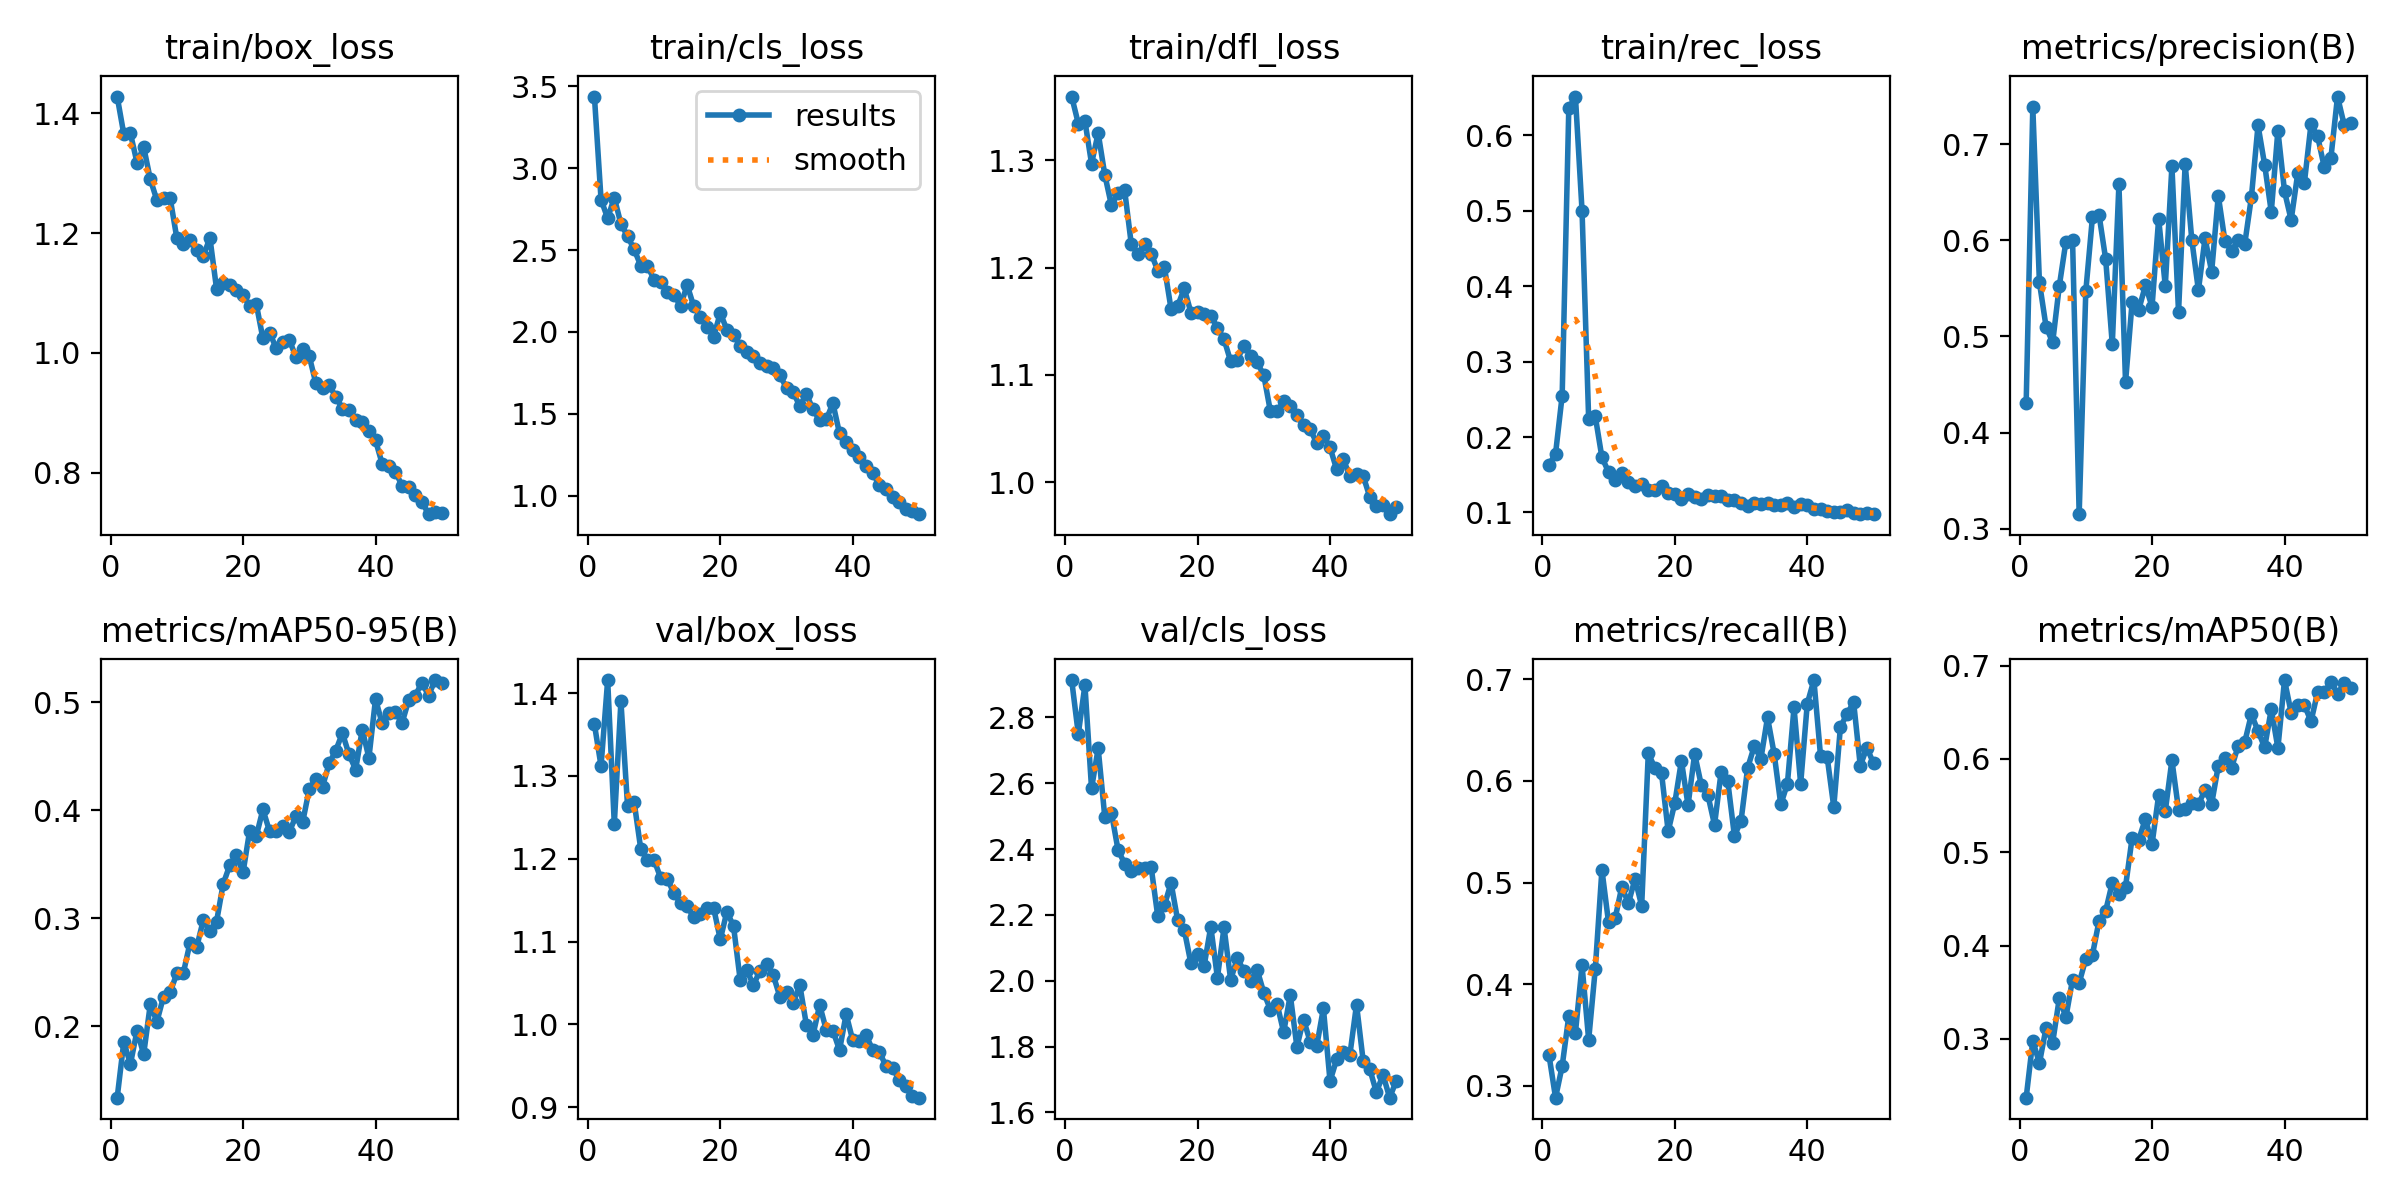

  ✅ Saved confusion_matrix.png


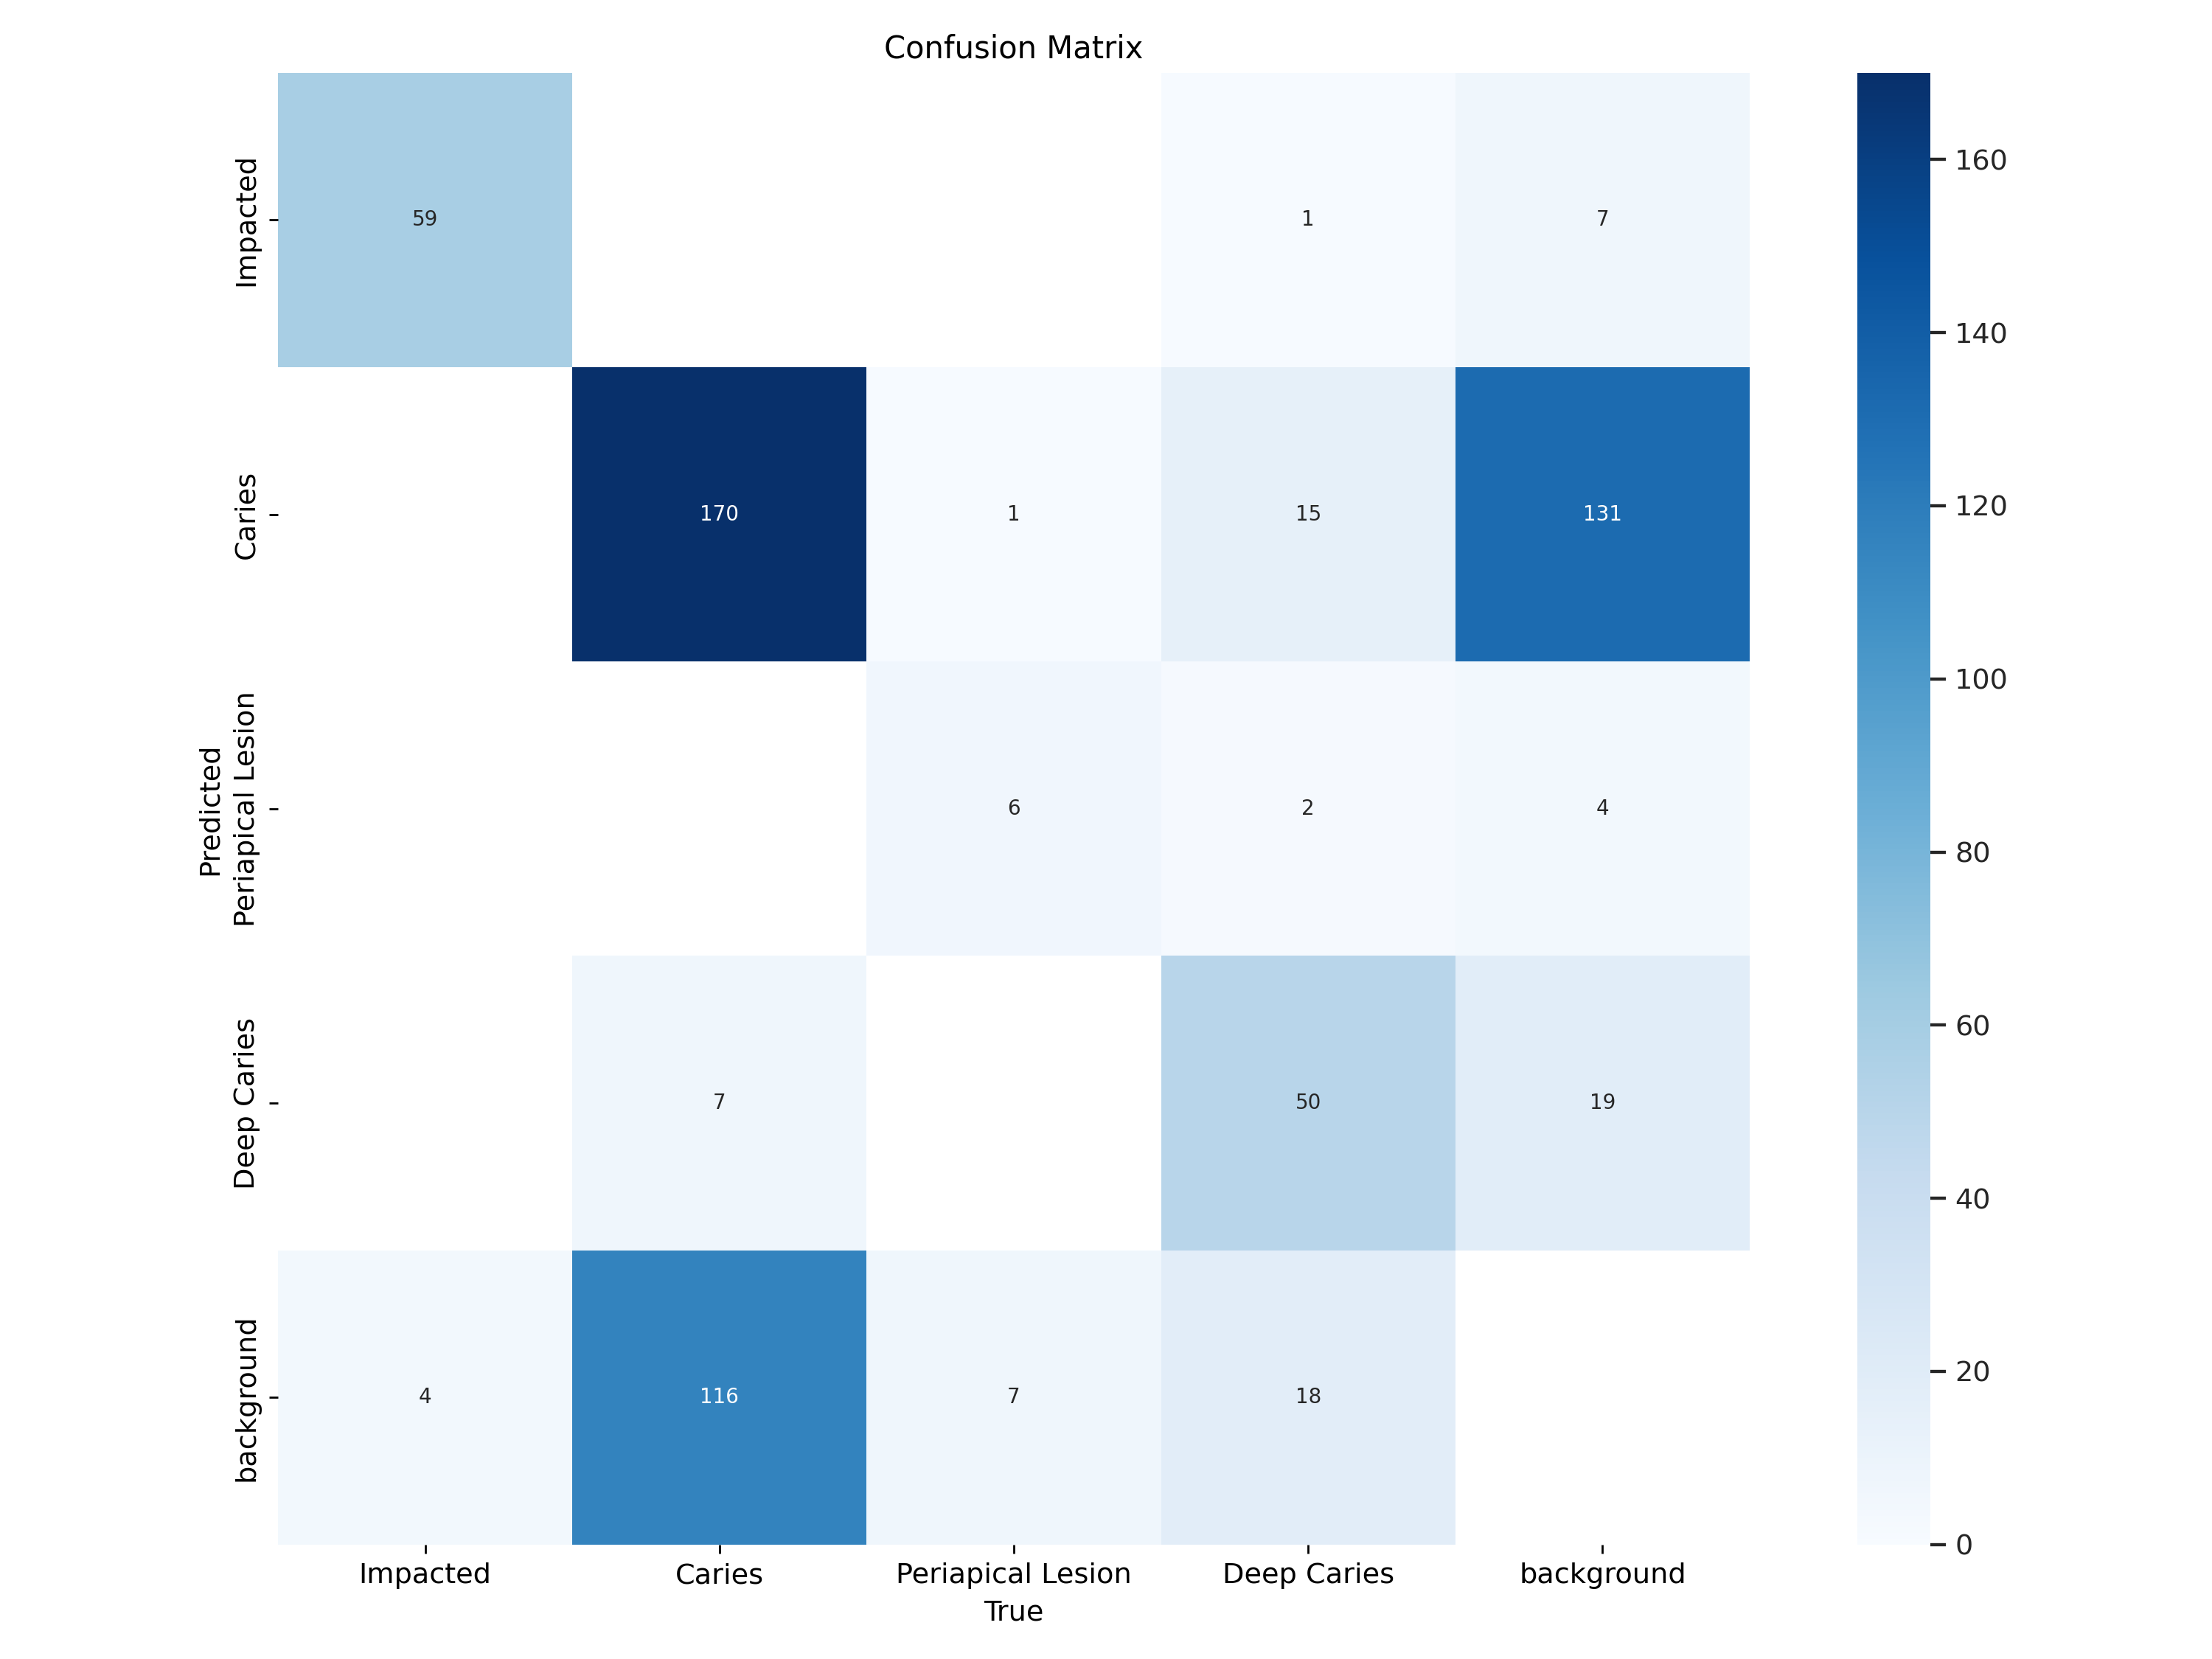

  ✅ Saved PR_curve.png


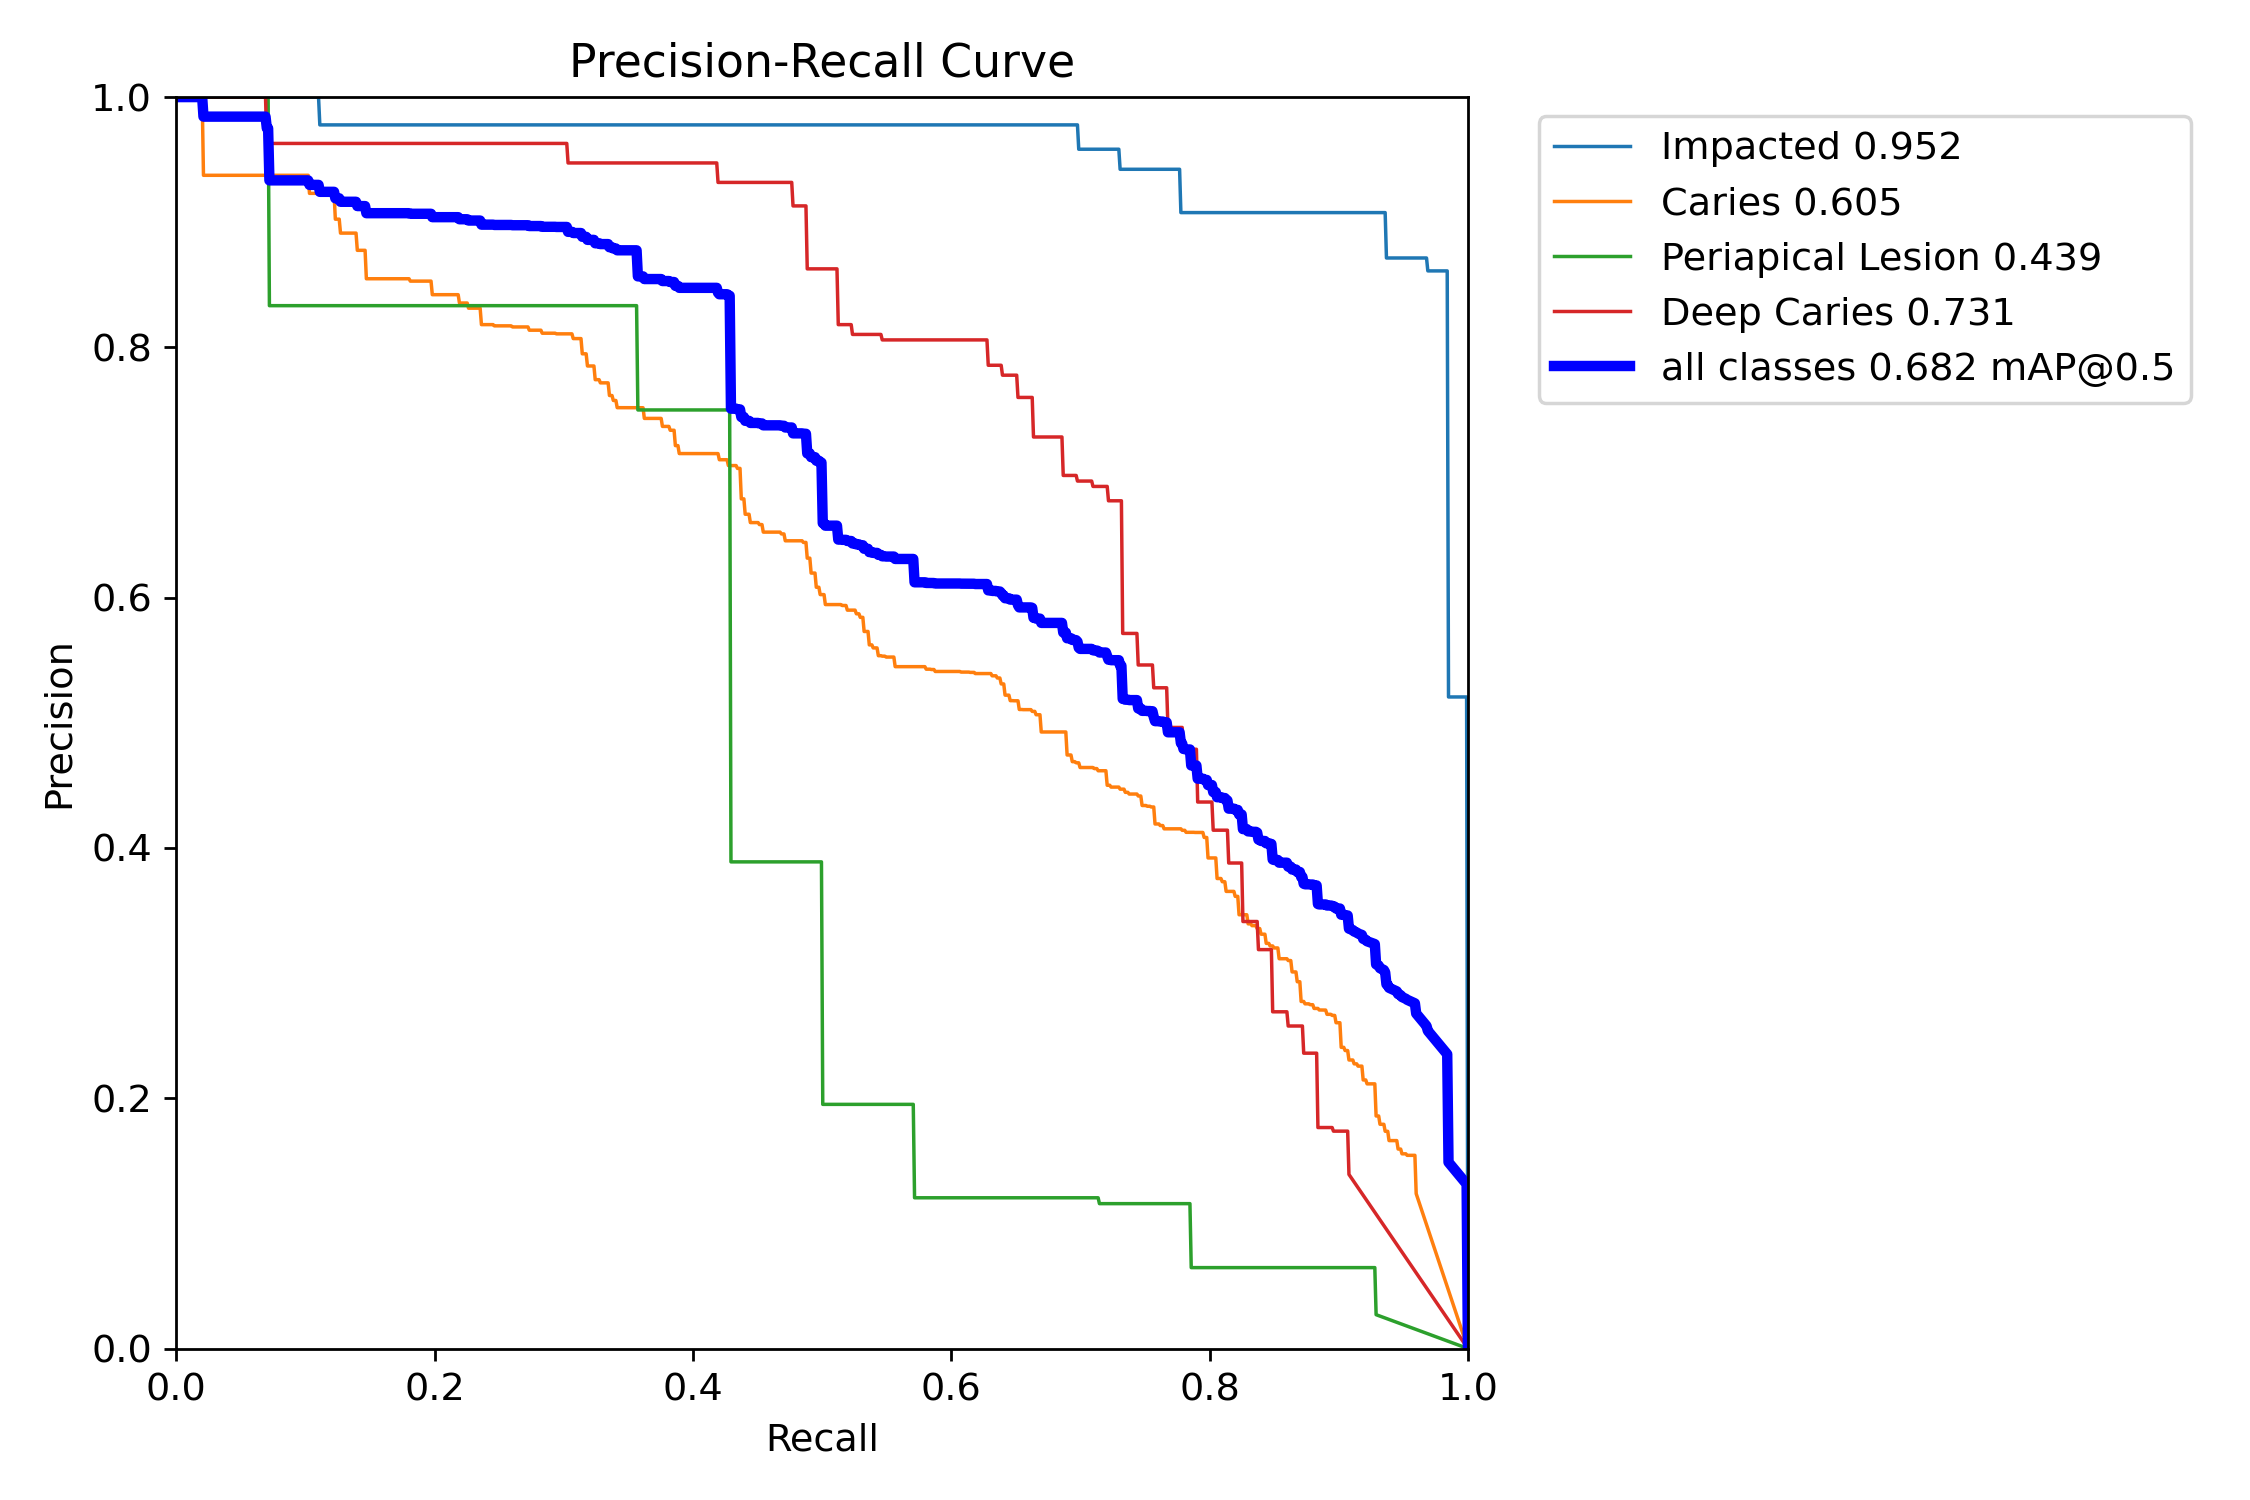

  ✅ Saved F1_curve.png


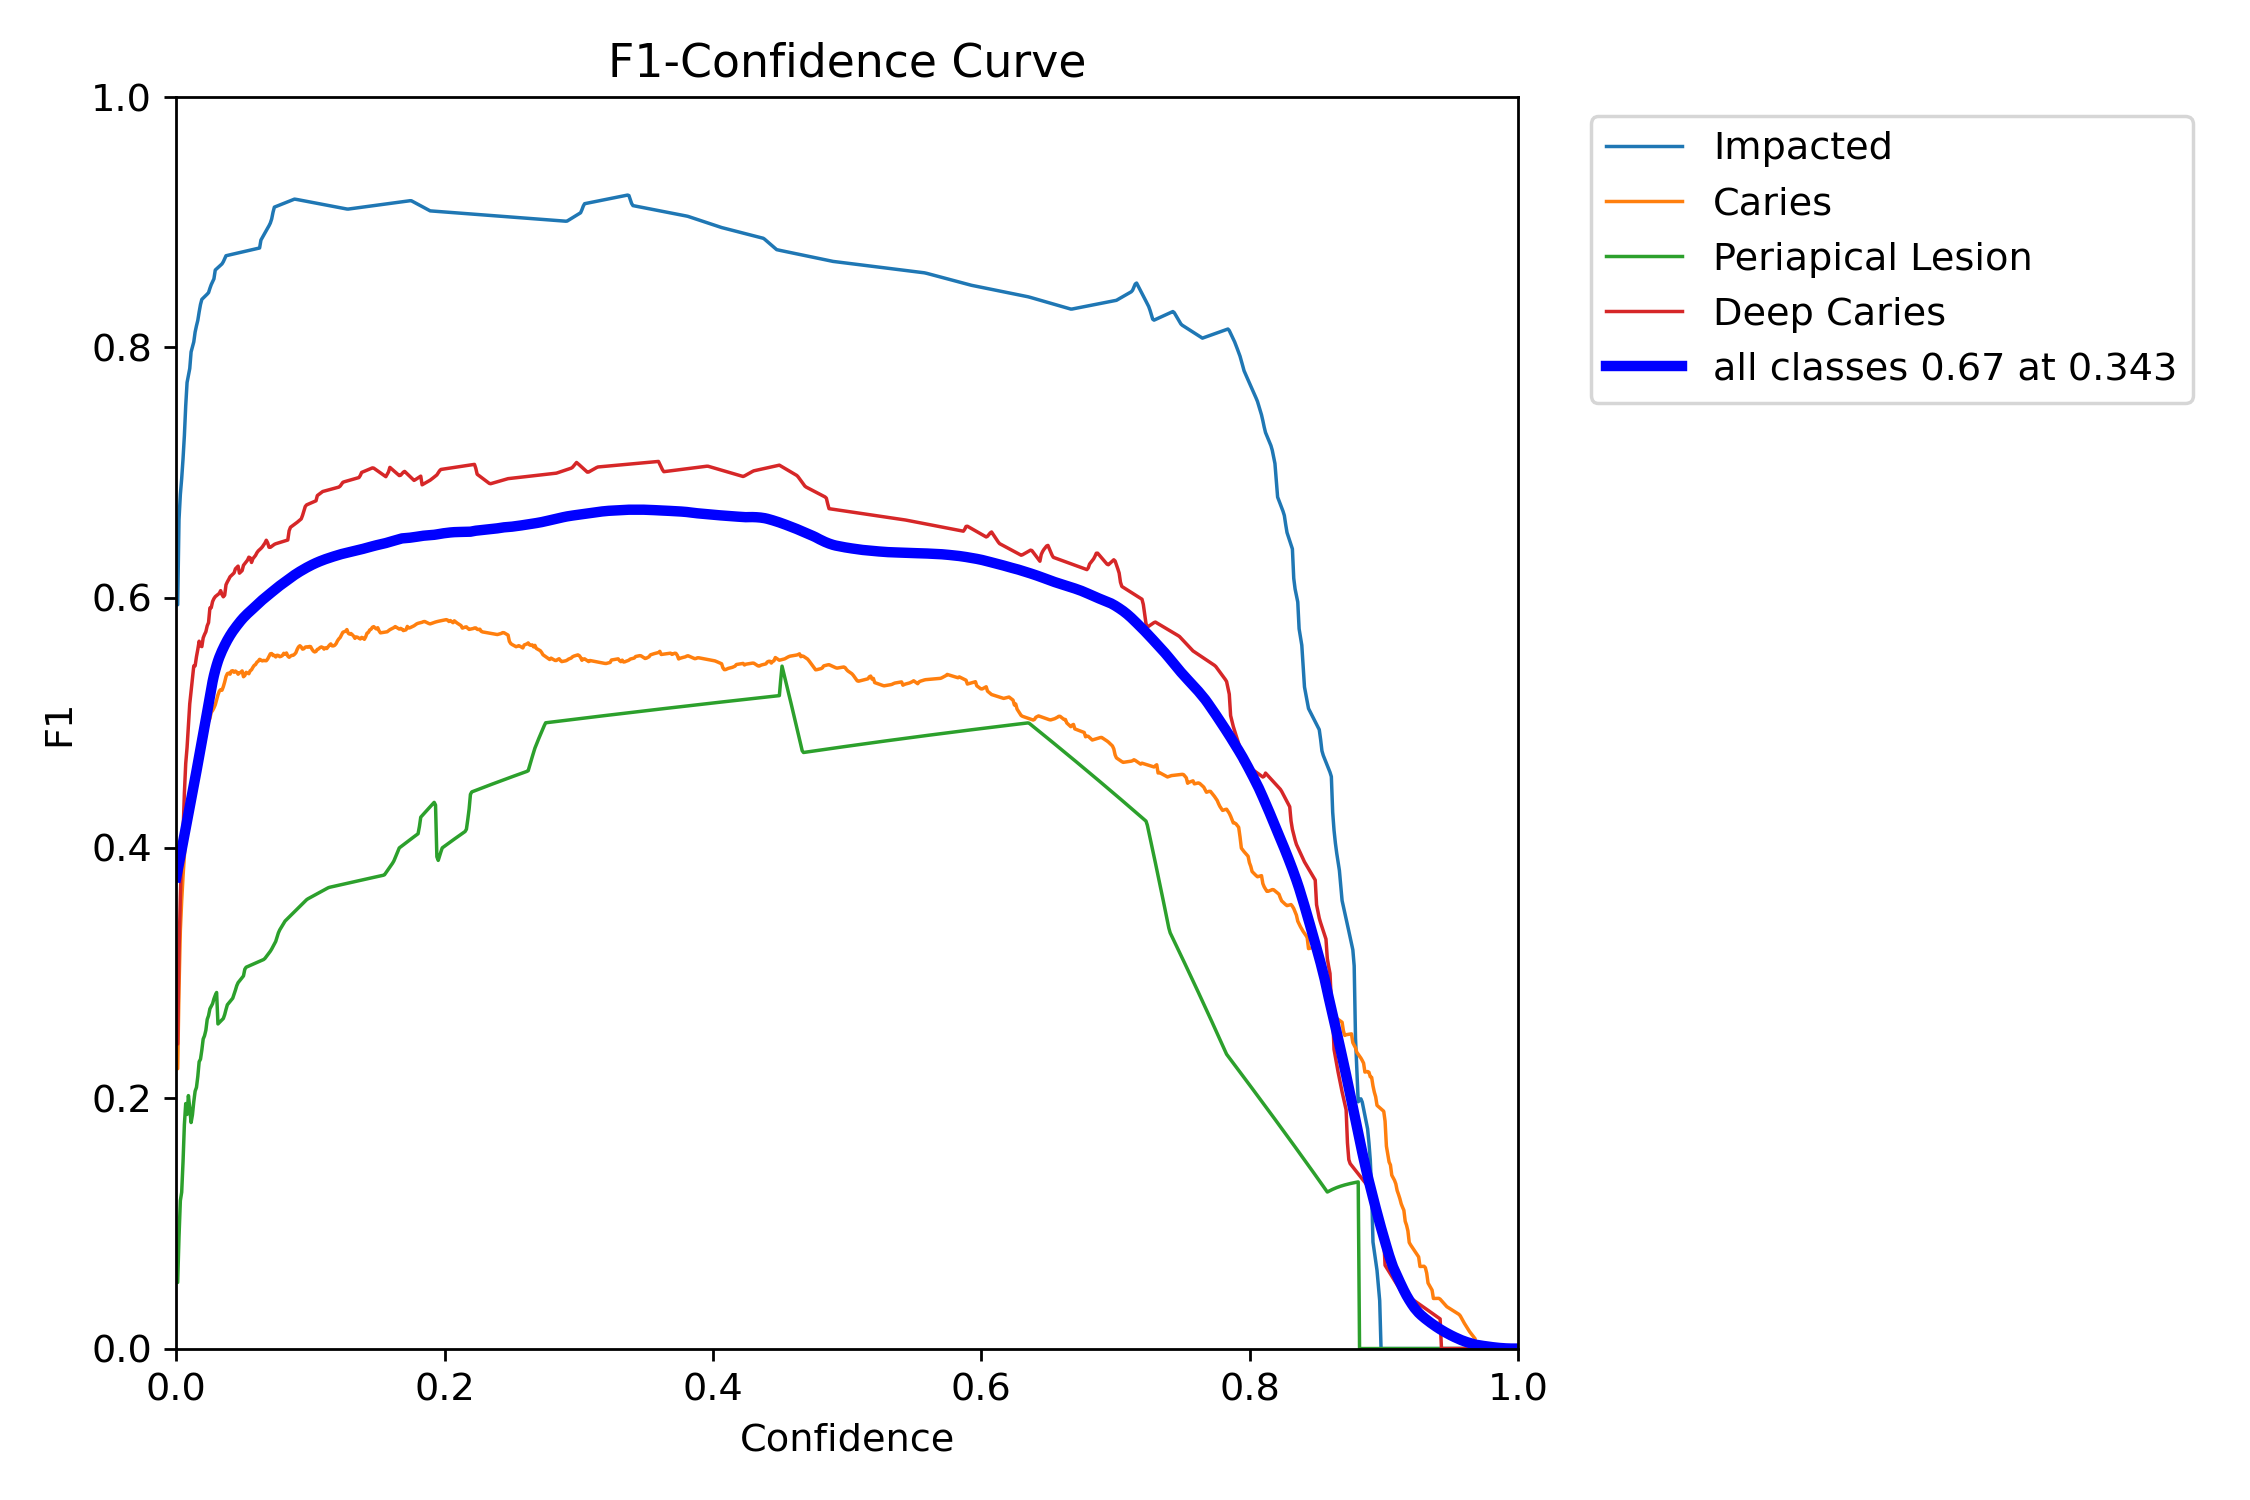

  ✅ Saved checkpoint: epoch45.pt
  ✅ Saved checkpoint: epoch5.pt
  ✅ Saved checkpoint: epoch15.pt
  ✅ Saved checkpoint: epoch40.pt
  ✅ Saved checkpoint: epoch25.pt
  ✅ Saved checkpoint: epoch10.pt
  ✅ Saved checkpoint: epoch35.pt
  ✅ Saved checkpoint: epoch30.pt
  ✅ Saved checkpoint: epoch20.pt


In [6]:
# ============ SAVE WEIGHTS TO GOOGLE DRIVE ============
import os, shutil
from IPython.display import Image as IPImage, display

SAVE_DIR = "/content/drive/MyDrive/YOLOv8_Dentex_2023/phase1_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

p1_dir = None
for root, dirs, files in os.walk("/content/SSAD/runs/ssad"):
    if "phase1" in os.path.basename(root) and os.path.exists(os.path.join(root, "weights")):
        p1_dir = root; break
print(f"Phase 1 run dir: {p1_dir}")

if p1_dir:
    w_dir = os.path.join(p1_dir, "weights")
    for pt in ["best.pt", "last.pt"]:
        src = os.path.join(w_dir, pt)
        dst = os.path.join(SAVE_DIR, f"phase1_{pt}")
        if os.path.exists(src):
            shutil.copy2(src, dst)
            print(f"  ✅ Saved {pt} → {dst} ({os.path.getsize(dst)/1024/1024:.1f} MB)")
    for img in ["results.png", "confusion_matrix.png", "PR_curve.png", "F1_curve.png"]:
        p = os.path.join(p1_dir, img)
        if os.path.exists(p):
            shutil.copy2(p, os.path.join(SAVE_DIR, img))
            print(f"  ✅ Saved {img}")
            display(IPImage(filename=p, width=800))
else:
    print("❌ Phase 1 run directory not found!")

# Lưu thêm checkpoint định kỳ (save_period) nếu có
ckpt_dir = os.path.join(SAVE_DIR, "checkpoints")
os.makedirs(ckpt_dir, exist_ok=True)
if p1_dir:
    for f in os.listdir(w_dir):
        if f.startswith("epoch") and f.endswith(".pt"):
            shutil.copy2(os.path.join(w_dir, f), os.path.join(ckpt_dir, f))
            print(f"  ✅ Saved checkpoint: {f}")


## 6. Phase 1: Test Inference vs Ground Truth

Inference on 165 test images (imgsz=640)...


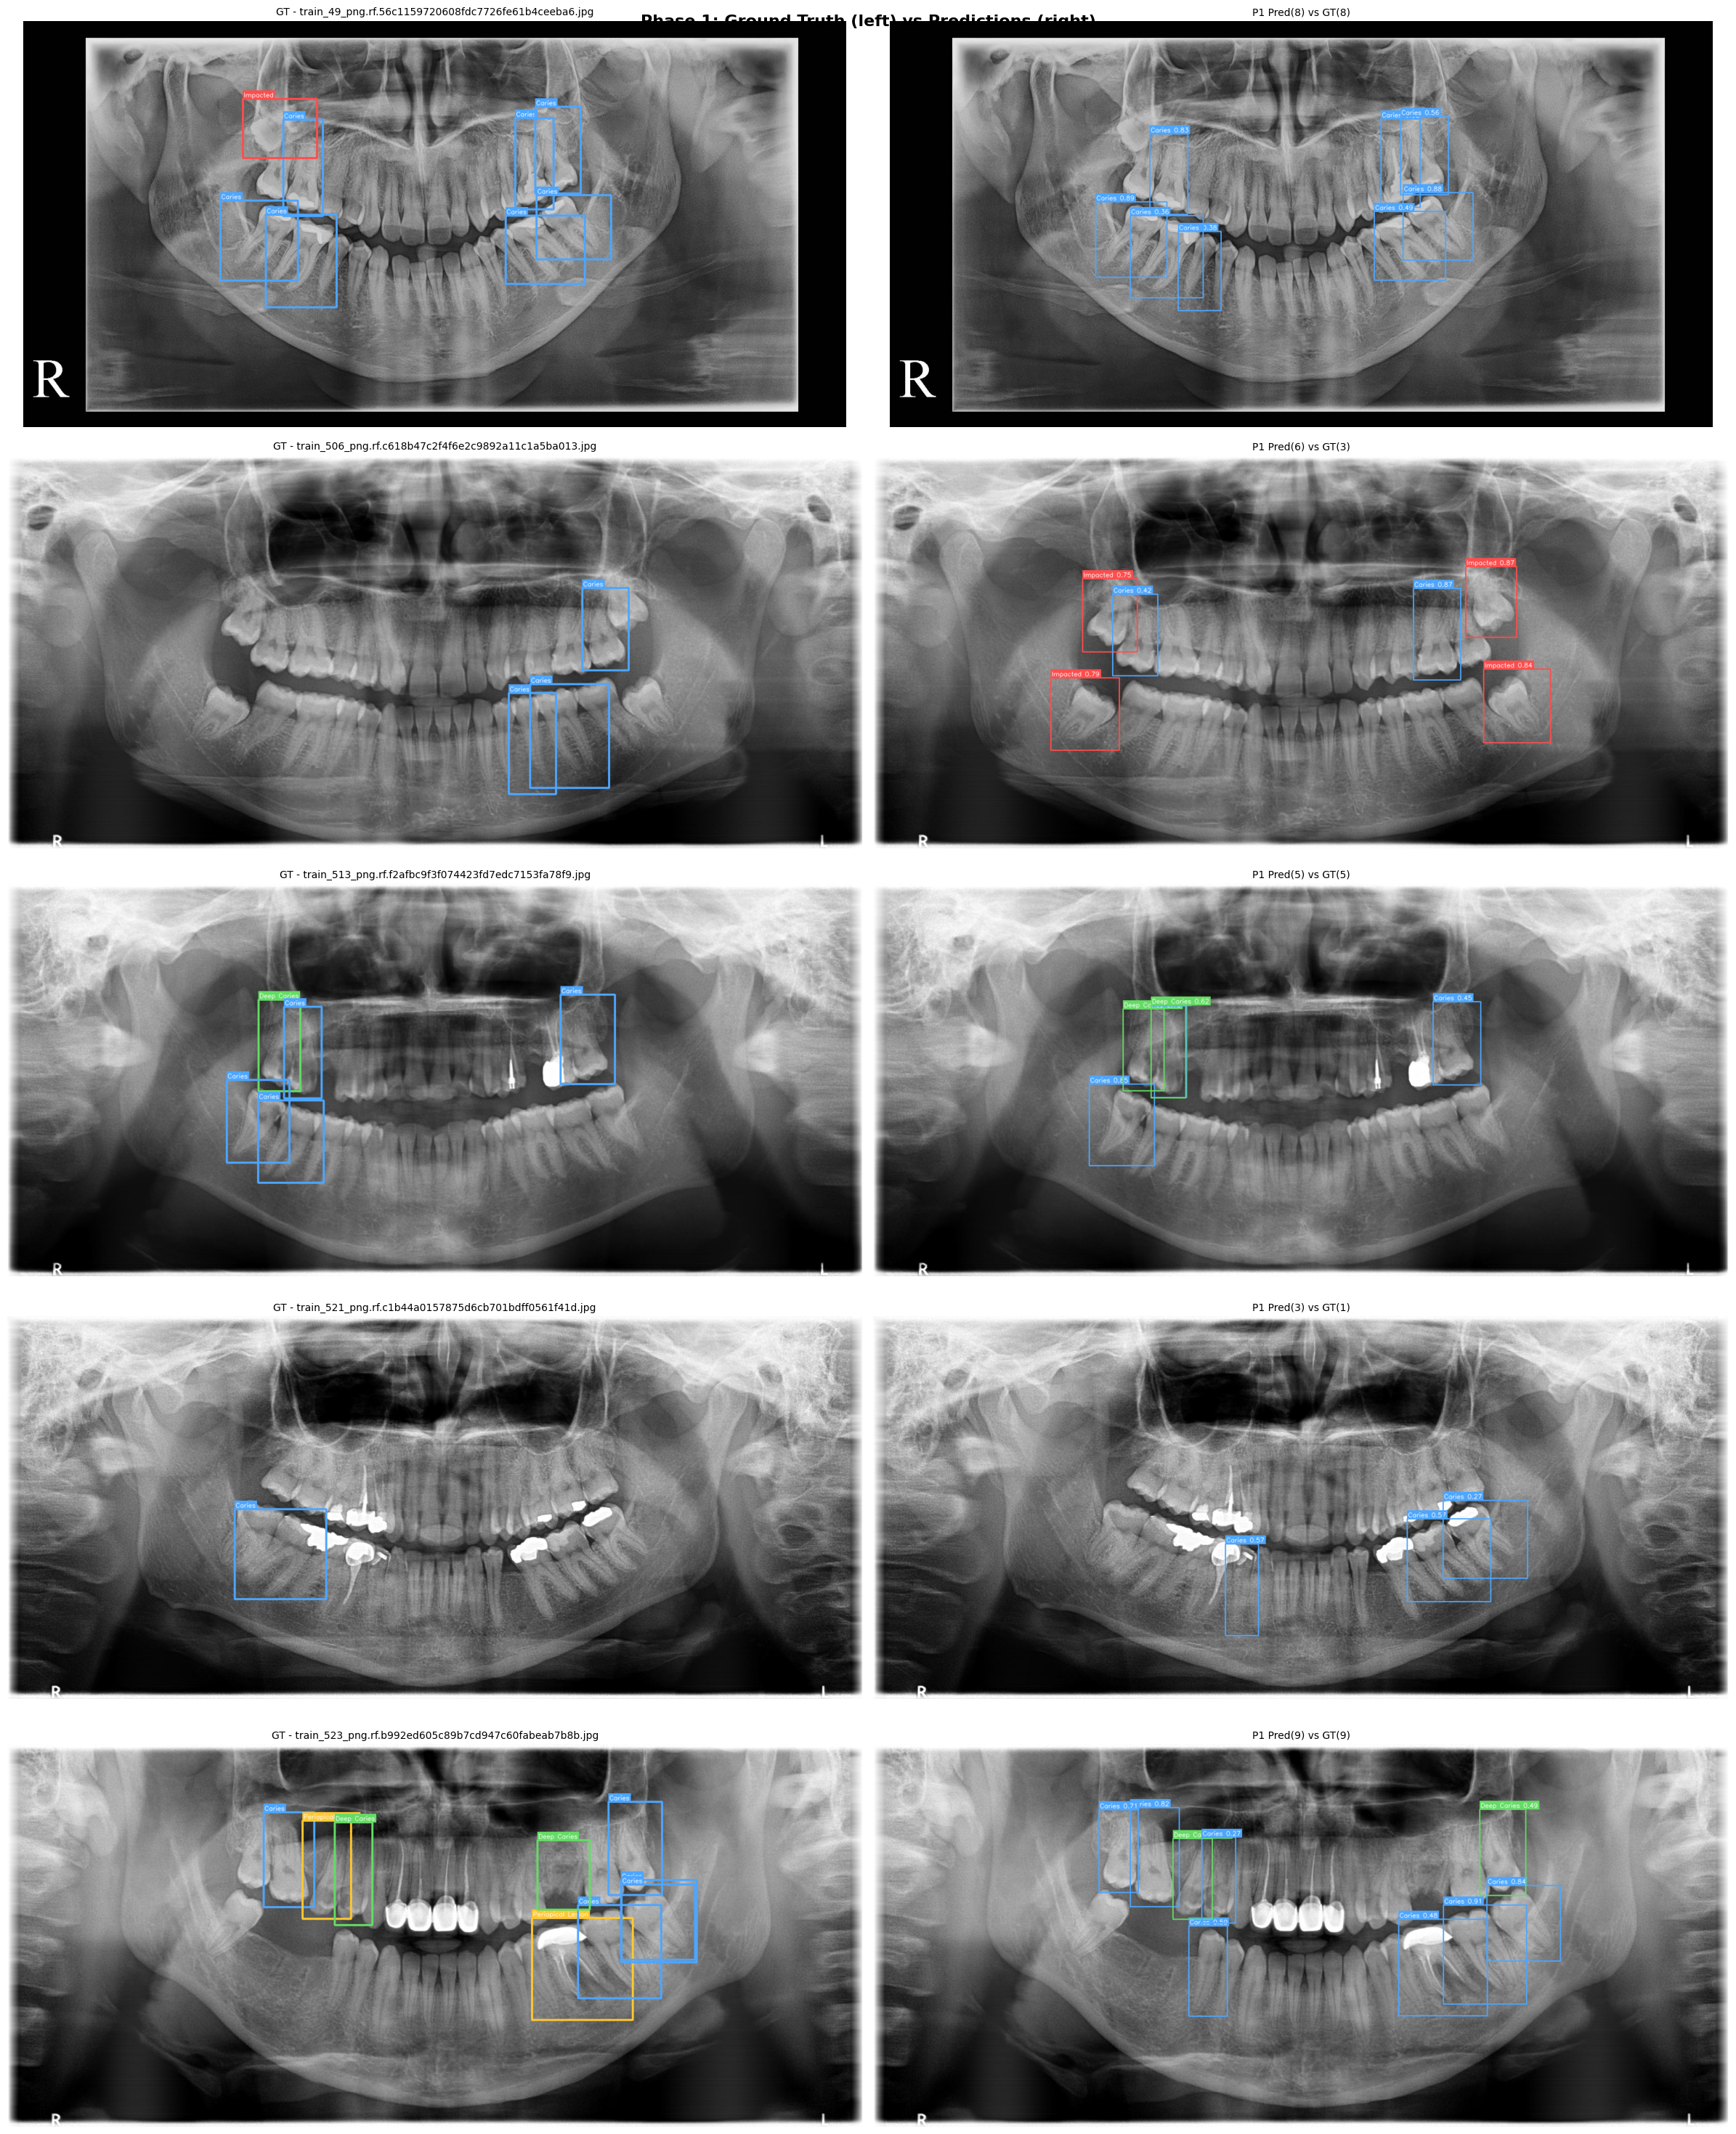

Saved comparison → /content/drive/MyDrive/YOLOv8_Dentex_2023/phase1_outputs/phase1_comparison.png
Phase 1 eval done!


In [10]:
# ============ PHASE 1: GT vs PRED ON TEST SET ============
import sys, os, cv2, numpy as np, matplotlib.pyplot as plt, gc, torch

WEIGHTS_DIR = "/content/SSAD/yolov8-ssad"
DST         = "/content/SSAD/yolov8-ssad/dentex_datasets"
SAVE_DIR    = "/content/drive/MyDrive/YOLOv8_Dentex_2023/phase1_outputs"
sys.path.insert(0, WEIGHTS_DIR)
from ultralytics.models import YOLO

p1_wt = os.path.join(SAVE_DIR, "phase1_best.pt")
if not os.path.exists(p1_wt):
    for r,d,f in os.walk("/content/SSAD"):
        if "best.pt" in f and "phase1" in r:
            p1_wt = os.path.join(r,"best.pt"); break

try:
    p1m = YOLO(p1_wt)
except:
    p1m = YOLO(p1_wt, task="ssad")

with open(f"{DST}/test.txt") as f: timgs=[l.strip() for l in f if l.strip()]
print(f"Inference on {len(timgs)} test images (imgsz=640)...")
NUM_VIZ = min(5, len(timgs))
p1res = p1m.predict(source=timgs[:NUM_VIZ], conf=0.25, iou=0.5, imgsz=640, batch=1, save=False, verbose=False)

NAMES={0:"Impacted",1:"Caries",2:"Periapical Lesion",3:"Deep Caries"}
COLS={0:(255,77,77),1:(77,166,255),2:(255,200,50),3:(100,220,100)}

def load_gt(lp):
    bx=[]
    if not os.path.exists(lp): return bx
    with open(lp) as f:
        for l in f:
            p=l.strip().split()
            if len(p)>=5: bx.append((int(p[0]),float(p[1]),float(p[2]),float(p[3]),float(p[4])))
    return bx

def draw(img,boxes,is_gt):
    h,w=img.shape[:2]; out=img.copy()
    for b in boxes:
        if is_gt: c,cx,cy,bw,bh=b; x1,y1=int((cx-bw/2)*w),int((cy-bh/2)*h); x2,y2=int((cx+bw/2)*w),int((cy+bh/2)*h); ct=""
        else: c,x1,y1,x2,y2,cf=b; x1,y1,x2,y2=int(x1),int(y1),int(x2),int(y2); ct=f" {cf:.2f}"
        col=COLS.get(c,(200,200,200)); cv2.rectangle(out,(x1,y1),(x2,y2),col,3 if is_gt else 2)
        lbl=f"{NAMES.get(c,str(c))}{ct}"; (tw,th),_=cv2.getTextSize(lbl,cv2.FONT_HERSHEY_SIMPLEX,0.5,1)
        cv2.rectangle(out,(x1,y1-th-8),(x1+tw+4,y1),col,-1)
        cv2.putText(out,lbl,(x1+2,y1-4),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),1,cv2.LINE_AA)
    return out

nd=NUM_VIZ
fig,axes=plt.subplots(nd,2,figsize=(24,6*nd))
if nd==1: axes=axes.reshape(1,-1)
for idx,(ip,res) in enumerate(zip(timgs[:NUM_VIZ],p1res)):
    img=cv2.cvtColor(cv2.imread(ip),cv2.COLOR_BGR2RGB)
    gt=load_gt(f"{DST}/labels/{os.path.splitext(os.path.basename(ip))[0]}.txt")
    gt_img=draw(img.copy(),gt,True); pbs=[]
    if res.boxes is not None and len(res.boxes):
        for bx in res.boxes: x1,y1,x2,y2=bx.xyxy[0].cpu().numpy(); pbs.append((int(bx.cls[0]),x1,y1,x2,y2,float(bx.conf[0])))
    pred_img=draw(img.copy(),pbs,False)
    axes[idx,0].imshow(gt_img); axes[idx,0].set_title(f"GT - {os.path.basename(ip)}",fontsize=10); axes[idx,0].axis("off")
    axes[idx,1].imshow(pred_img); axes[idx,1].set_title(f"P1 Pred({len(pbs)}) vs GT({len(gt)})",fontsize=10); axes[idx,1].axis("off")

plt.suptitle("Phase 1: Ground Truth (left) vs Predictions (right)", fontsize=16, fontweight="bold")
plt.tight_layout()
out_png = os.path.join(SAVE_DIR, "phase1_comparison.png")
plt.savefig(out_png, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved comparison → {out_png}")
del p1m,p1res; gc.collect(); torch.cuda.empty_cache()
print("Phase 1 eval done!")

Free VRAM trước khi load model: 13210 MB
Weights: /content/drive/MyDrive/YOLOv8_Dentex_2023/phase1_outputs/phase1_best.pt
Model loaded — eval mode, gradients disabled.
Total test images: 165
  20/165 done | VRAM used: 1340 MB
  40/165 done | VRAM used: 1340 MB
  60/165 done | VRAM used: 1340 MB
  80/165 done | VRAM used: 1340 MB
  100/165 done | VRAM used: 1340 MB
  120/165 done | VRAM used: 1340 MB
  140/165 done | VRAM used: 1340 MB
  160/165 done | VRAM used: 1340 MB

Finished! Saved 165 images → /content/drive/MyDrive/YOLOv8_Dentex_2023/phase1_outputs/GT_vs_Pred_Test


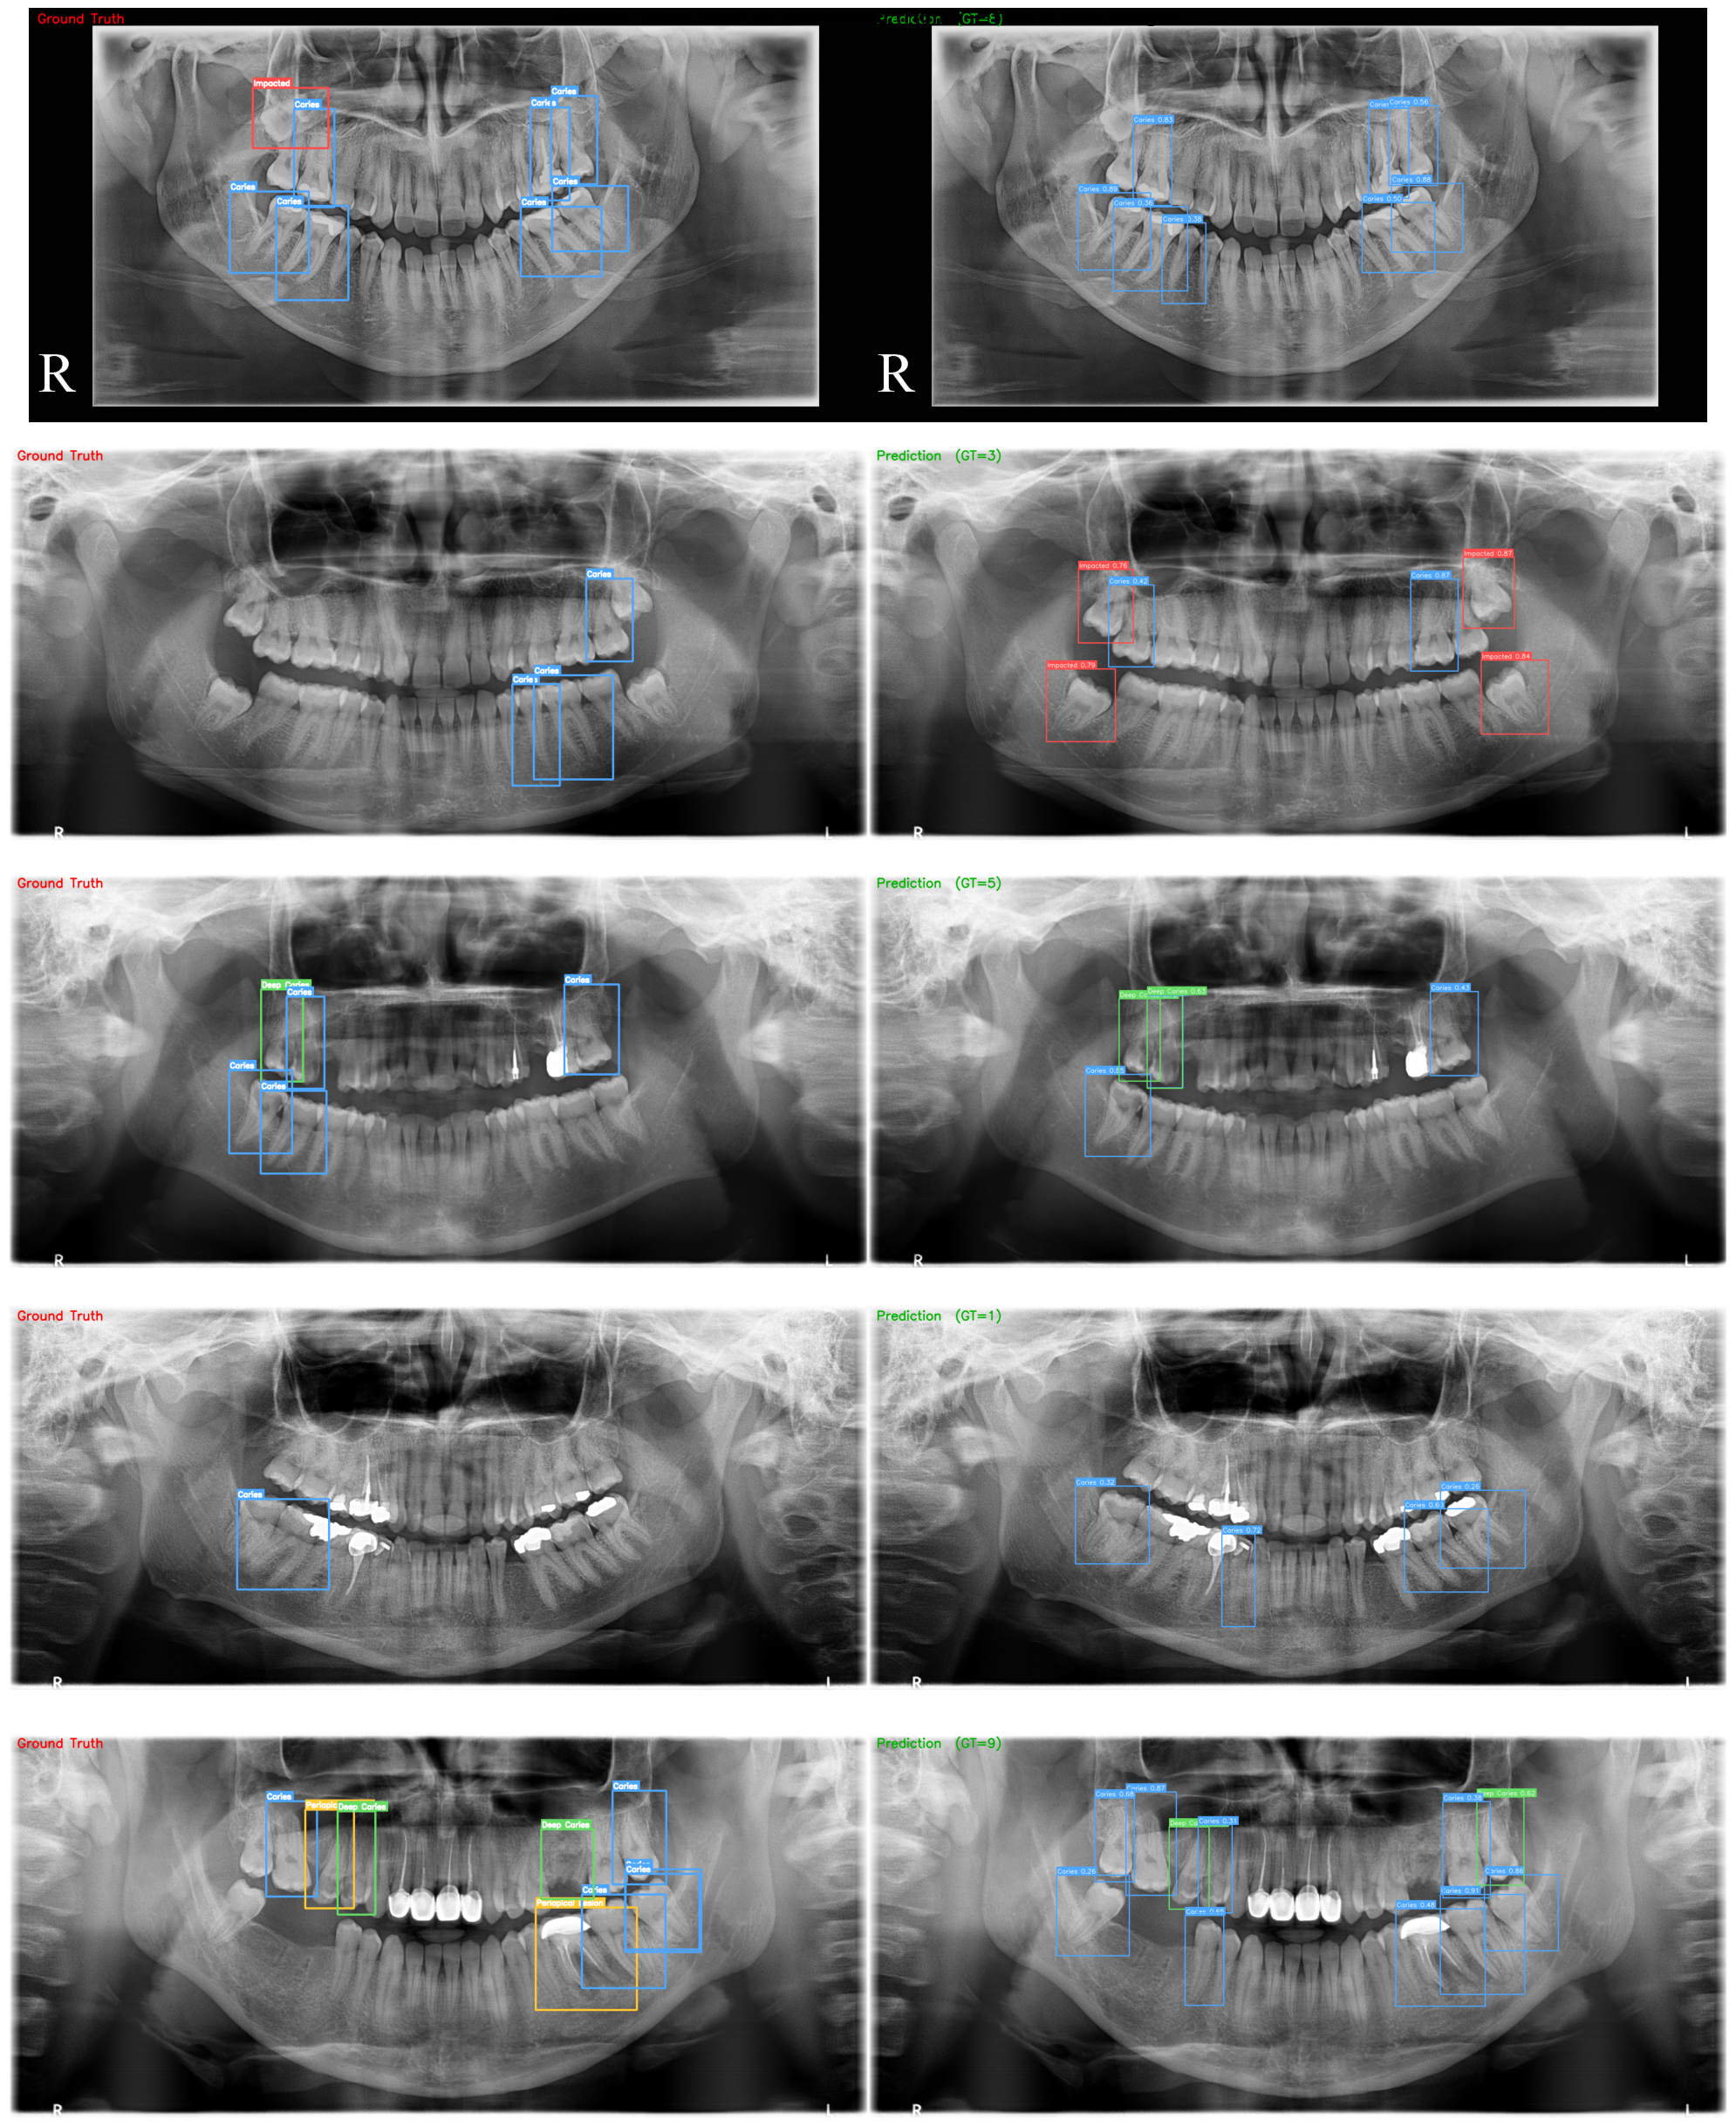

Preview saved → /content/drive/MyDrive/YOLOv8_Dentex_2023/phase1_outputs/phase1_comparison_preview.png
Done.


In [14]:
# =========================
# GT vs Prediction — FULL TEST SET
# Save all comparison images to Google Drive
# =========================

import os, sys, gc, cv2, torch
import numpy as np
import matplotlib.pyplot as plt

WEIGHTS_DIR = "/content/SSAD/yolov8-ssad"
DST         = "/content/SSAD/yolov8-ssad/dentex_datasets"
SAVE_DIR    = "/content/drive/MyDrive/YOLOv8_Dentex_2023/phase1_outputs"
COMPARE_DIR = os.path.join(SAVE_DIR, "GT_vs_Pred_Test")
os.makedirs(COMPARE_DIR, exist_ok=True)

sys.path.insert(0, WEIGHTS_DIR)

# ── Fix 1: xóa VRAM còn lại từ training ──────────────────────────────────────
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
free_mb = torch.cuda.mem_get_info()[0] / 1024**2
print(f"Free VRAM trước khi load model: {free_mb:.0f} MB")
assert free_mb > 2000, f"❌ VRAM quá thấp ({free_mb:.0f} MB). Restart runtime rồi chạy lại cell này."

# ── Load model ────────────────────────────────────────────────────────────────
from ultralytics.models import YOLO

p1_wt = os.path.join(SAVE_DIR, "phase1_best.pt")
if not os.path.exists(p1_wt):
    for r, d, f in os.walk("/content/SSAD"):
        if "best.pt" in f and "phase1" in r:
            p1_wt = os.path.join(r, "best.pt")
            break
assert os.path.exists(p1_wt), f"❌ Không tìm thấy weights: {p1_wt}"
print(f"Weights: {p1_wt}")

model = YOLO(p1_wt)

# ── Fix 2: eval mode + tắt gradient ──────────────────────────────────────────
model.model.eval()
for p in model.model.parameters():
    p.requires_grad = False

print("Model loaded — eval mode, gradients disabled.")

# ── Load test list ────────────────────────────────────────────────────────────
with open(f"{DST}/test.txt") as f:
    test_imgs = [x.strip() for x in f if x.strip()]
print(f"Total test images: {len(test_imgs)}")

# ── Class names + colors ──────────────────────────────────────────────────────
NAMES = {
    0: "Impacted",
    1: "Caries",
    2: "Periapical Lesion",
    3: "Deep Caries",
}
COLORS = {
    0: (255, 77,  77),
    1: (77,  166, 255),
    2: (255, 200, 50),
    3: (100, 220, 100),
}

# ── Helper: load GT ───────────────────────────────────────────────────────────
def load_gt(label_path):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) >= 5:
                boxes.append((int(p[0]), float(p[1]), float(p[2]),
                               float(p[3]), float(p[4])))
    return boxes

# ── Helper: draw GT boxes ─────────────────────────────────────────────────────
def draw_gt(img, boxes):
    h, w = img.shape[:2]
    out  = img.copy()
    for cls, cx, cy, bw, bh in boxes:
        x1 = int((cx - bw / 2) * w)
        y1 = int((cy - bh / 2) * h)
        x2 = int((cx + bw / 2) * w)
        y2 = int((cy + bh / 2) * h)
        color = COLORS.get(cls, (0, 255, 0))
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 3)
        label = NAMES.get(cls, str(cls))
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(out, (x1, y1 - th - 10), (x1 + tw + 5, y1), color, -1)
        cv2.putText(out, label, (x1 + 2, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
    return out

# ── Helper: draw Prediction boxes ────────────────────────────────────────────
def draw_pred(img, result):
    out = img.copy()
    if result.boxes is None or len(result.boxes) == 0:
        return out
    for box in result.boxes:
        cls  = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        color = COLORS.get(cls, (0, 255, 0))
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        label = f"{NAMES.get(cls, str(cls))} {conf:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(out, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
        cv2.putText(out, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
    return out

# ── Fix 3: inference loop với no_grad + cleanup ngay mỗi iteration ───────────
preview = []

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

with torch.no_grad():
    for idx, img_path in enumerate(test_imgs):

        img = cv2.imread(img_path)
        if img is None:
            print(f"  ⚠ Không đọc được: {img_path}")
            continue

        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        label_path = img_path.replace("/images/", "/labels/")
        label_path = os.path.splitext(label_path)[0] + ".txt"
        gt_boxes   = load_gt(label_path)
        gt_img     = draw_gt(rgb.copy(), gt_boxes)

        result = model.predict(
            source=img_path,
            imgsz=640,
            conf=0.25,
            iou=0.5,
            verbose=False,
            save=False,
        )[0]

        pred_img = draw_pred(rgb.copy(), result)

        # Ghép GT (trái) + Pred (phải)
        compare = np.concatenate([gt_img, pred_img], axis=1)
        mid     = compare.shape[1] // 2

        cv2.putText(compare, "Ground Truth",
                    (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)
        cv2.putText(compare, f"Prediction  (GT={len(gt_boxes)})",
                    (mid + 20, 35), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 180, 0), 2, cv2.LINE_AA)

        save_path = os.path.join(COMPARE_DIR, os.path.basename(img_path))
        cv2.imwrite(save_path, cv2.cvtColor(compare, cv2.COLOR_RGB2BGR))

        if len(preview) < 5:
            preview.append(compare.copy())

        # Cleanup ngay — không đợi Python GC
        del result, img, rgb, gt_img, pred_img, compare

        if (idx + 1) % 20 == 0:
            gc.collect()
            torch.cuda.empty_cache()
            used_mb = torch.cuda.memory_allocated() / 1024**2
            print(f"  {idx+1}/{len(test_imgs)} done | VRAM used: {used_mb:.0f} MB")

print(f"\nFinished! Saved {len(test_imgs)} images → {COMPARE_DIR}")

# ── Hiển thị 5 ảnh đầu ───────────────────────────────────────────────────────
if preview:
    fig, axes = plt.subplots(len(preview), 1, figsize=(20, 5 * len(preview)))
    if len(preview) == 1:
        axes = [axes]
    for ax, img in zip(axes, preview):
        ax.imshow(img)
        ax.axis("off")
    plt.suptitle("Ground Truth (left) vs Prediction (right) — first 5 test images",
                 fontsize=15, fontweight="bold")
    plt.tight_layout()
    out_png = os.path.join(SAVE_DIR, "phase1_comparison_preview.png")
    plt.savefig(out_png, dpi=100, bbox_inches="tight")
    plt.show()
    print(f"Preview saved → {out_png}")

# ── Final cleanup ─────────────────────────────────────────────────────────────
del model, preview
gc.collect()
torch.cuda.empty_cache()
print("Done.")
